In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [14]:
df0 = pd.read_csv('./models/BFreqRatiosUncertain.csv', skiprows=2,
                 usecols=[0,2,3,4,5], names=['Freq', 'Rb85', 'Rb85_err', 'Rb87', 'Rb87_err'])
df1 = pd.read_csv('./models/quadraticRb85ZeemanData.csv', skiprows=2,
                 usecols=[0,2,3,4,5,6,7,8,9,10,11,12,13], names=['Freq','dip1','udip1','dip2','udip2','dip3','udip3','dip4','udip4','dip5','udip5','dip6','udip6'])
df2 = pd.read_csv('./models/quadraticRb87ZeemanData.csv', skiprows=2,
                 usecols=[0,2,3,4,5,6,7,8,9], names=['Freq','dip1','udip1','dip2','udip2','dip3','udip3','dip4','udip4'])

freqLow = df0['Freq'].values / 1000 # MHz
freq85High = df1['Freq'].values # MHz
freq87High = df2['Freq'].values # MHz


Rb85Low = df0['Rb85'].values # B field in T
uRb85Low = df0['Rb85_err'].values # B field in T

Rb87Low = df0['Rb87'].values # B field in T
uRb87Low = df0['Rb87_err'].values # B field in T


Rb85HighD1 = df1['dip1'].values # B field in T
Rb85HighD2 = df1['dip2'].values # B field in T
Rb85HighD3 = df1['dip3'].values # B field in T
Rb85HighD4 = df1['dip4'].values # B field in T
Rb85HighD5 = df1['dip5'].values # B field in T
Rb85HighD6 = df1['dip6'].values # B field in T
uRb85HighD1 = df1['udip1'].values # B field in T
uRb85HighD2 = df1['udip2'].values # B field in T
uRb85HighD3 = df1['udip3'].values # B field in T
uRb85HighD4 = df1['udip4'].values # B field in T
uRb85HighD5 = df1['udip5'].values # B field in T
uRb85HighD6 = df1['udip6'].values # B field in T

Rb87HighD1 = df2['dip1'].values # B field in T
Rb87HighD2 = df2['dip2'].values # B field in T
Rb87HighD3 = df2['dip3'].values # B field in T
Rb87HighD4 = df2['dip4'].values # B field in T
uRb87HighD1 = df2['udip1'].values # B field in T
uRb87HighD2 = df2['udip2'].values # B field in T
uRb87HighD3 = df2['udip3'].values # B field in T
uRb87HighD4 = df2['udip4'].values # B field in T


freq85 = np.concatenate((freqLow, freq85High))

Rb85d1 = np.concatenate((Rb85Low,Rb85HighD1))
Rb85d2 = np.concatenate((Rb85Low,Rb85HighD2))
Rb85d3 = np.concatenate((Rb85Low,Rb85HighD3))
Rb85d4 = np.concatenate((Rb85Low,Rb85HighD4))
Rb85d5 = np.concatenate((Rb85Low,Rb85HighD5))
Rb85d6 = np.concatenate((Rb85Low,Rb85HighD6))

uRb85d1 = np.concatenate((uRb85Low,uRb85HighD1))
uRb85d2 = np.concatenate((uRb85Low,uRb85HighD2))
uRb85d3 = np.concatenate((uRb85Low,uRb85HighD3))
uRb85d4 = np.concatenate((uRb85Low,uRb85HighD4))
uRb85d5 = np.concatenate((uRb85Low,uRb85HighD5))
uRb85d6 = np.concatenate((uRb85Low,uRb85HighD6))


freq87 = np.concatenate((freqLow, freq87High))

Rb87d1 = np.concatenate((Rb87Low,Rb87HighD1))
Rb87d2 = np.concatenate((Rb87Low,Rb87HighD2))
Rb87d3 = np.concatenate((Rb87Low,Rb87HighD3))
Rb87d4 = np.concatenate((Rb87Low,Rb87HighD4))

uRb87d1 = np.concatenate((uRb87Low,uRb87HighD1))
uRb87d2 = np.concatenate((uRb87Low,uRb87HighD2))
uRb87d3 = np.concatenate((uRb87Low,uRb87HighD3))
uRb87d4 = np.concatenate((uRb87Low,uRb87HighD4))

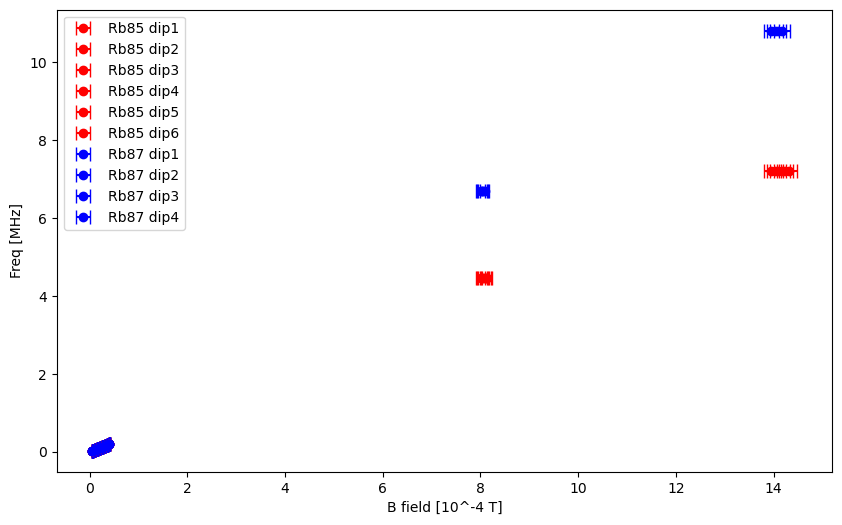

In [17]:
plt.figure(figsize=(10, 6))
plt.errorbar(Rb85d1 * 10**4, freq85,xerr=uRb85d1 * 10**4, capsize=5, label='Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d2 * 10**4, freq85,xerr=uRb85d2 * 10**4, capsize=5, label='Rb85 dip2', fmt='o', color='red')
plt.errorbar(Rb85d3 * 10**4, freq85, xerr=uRb85d3 * 10**4, capsize=5, label='Rb85 dip3', fmt='o', color='red')
plt.errorbar(Rb85d4 * 10**4, freq85, xerr=uRb85d4 * 10**4, capsize=5, label='Rb85 dip4', fmt='o', color='red')
plt.errorbar(Rb85d5 * 10**4, freq85, xerr=uRb85d5 * 10**4, capsize=5, label='Rb85 dip5', fmt='o', color='red')
plt.errorbar(Rb85d6 * 10**4, freq85, xerr=uRb85d6 * 10**4, capsize=5, label='Rb85 dip6', fmt='o', color='red')


plt.errorbar(Rb85d1 * 10**4, freq87, xerr=uRb87d1 * 10**4, capsize=5, label='Rb87 dip1', fmt='o', color='blue')
plt.errorbar(Rb85d2 * 10**4, freq87, xerr=uRb87d2 * 10**4, capsize=5, label='Rb87 dip2', fmt='o', color='blue')
plt.errorbar(Rb85d3 * 10**4, freq87, xerr=uRb87d3 * 10**4, capsize=5, label='Rb87 dip3', fmt='o', color='blue')
plt.errorbar(Rb85d4 * 10**4, freq87, xerr=uRb87d4 * 10**4, capsize=5, label='Rb87 dip4', fmt='o', color='blue')


# Labels and formatting
plt.ylabel('Freq [MHz]')
plt.xlabel('B field [10^-4 T]')
# plt.title('B for transmission')
plt.legend()
plt.savefig("./figures/gfactor quadratic range Mar13", dpi=300)

plt.show()

Slope ratio: (1.501+/-0.032)e+00
Tscore : 2.630e-02


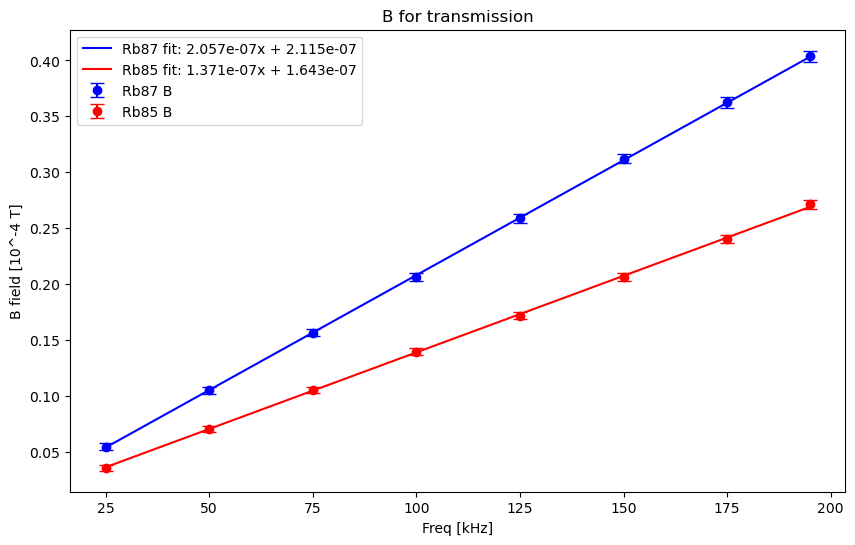

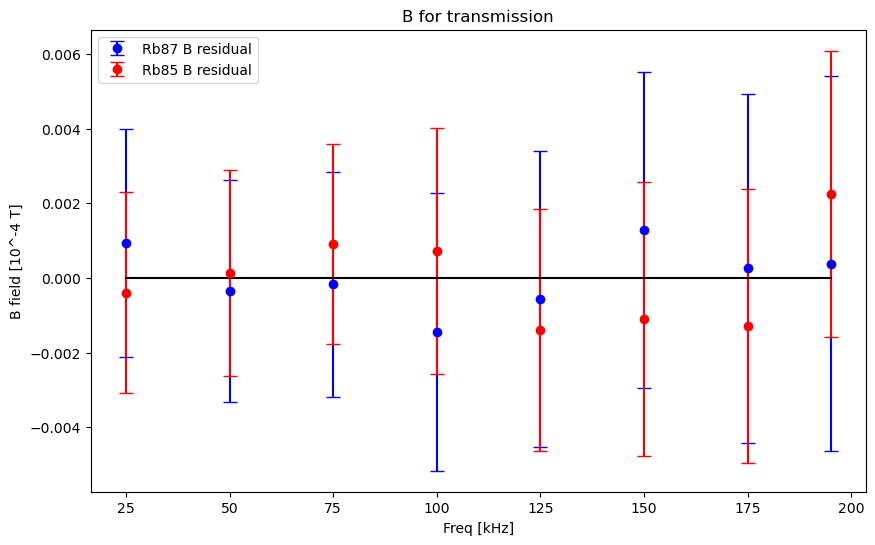